# PIMA Diabetes Project

Violetta Tokhtamysh

#1 - Description


This project uses the PIMA Indians Diabetes Dataset, which contains medical diagnostic measurements collected from women aged 21 and older.
The purpose of the dataset is to determine whether a patient has diabetes (Outcome = 1) or not (Outcome = 0) based on several clinical features.

[PIMA Indians Diabetes Dataset](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

Content (9 variables):

* Pregnancies – Number of times pregnant
* Glucose – Plasma glucose concentration
* BloodPressure – Diastolic blood pressure (mm Hg)
* SkinThickness – Triceps skin fold thickness (mm)
* Insulin – 2-Hour serum insulin (mu U/ml)
* BMI – Body mass index (weight in kg/(height in m)^2)
* DiabetesPedigree – Diabetes pedigree function (genetic influence)
* Age – Age in years
* Outcome – 1=diabetes, 0=no diabetes


SMOTE improves the quality of simple models (Decision Tree, MLP),
but does not necessarily help CNN-1D, and sometimes even worsens training due to distortion of the spatial structure of the data.

#2 -  Goal:
The goal of this project is to build and evaluate machine learning and neural network models that can predict the presence of diabetes based on medical measurements.


#3 - Objectives:
* Perform data preparation: replace invalid zero values, clean the dataset, handle missing information and outliers.

* Conduct exploratory data analysis, including histograms, distribution plots, and a correlation heatmap.

* Train traditional machine learning models (Decision Tree).

* Train neural network models (MLP and CNN1D) for comparison.

* Apply SMOTE to handle class imbalance and evaluate its effect on model performance.

* Assess models using precision, recall, f1-score, accuracy, confusion matrix, and ROC.

* Compare all methods and determine which approach performs best for diabetes prediction.



#4 - Preparing Data
In this section, I connected all the libraries needed for data processing and model training.

The main goal of this step is to prepare the working environment and tools so that the data can be processed correctly and the three types of models can be trained.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

# ML tools
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Classical ML
from sklearn.tree import DecisionTreeClassifier

# SMOTE
from imblearn.over_sampling import SMOTE

# Neural Networks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout,
    Conv1D, GlobalMaxPooling1D
)

##4.1 - Reading the Data
In this step, I downloaded the Pima Indians Diabetes dataset directly from an open GitHub repository.
Since the file does not contain headers, I manually specified a list of columns to make the data readable and to make it easier to work with the features later on.

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    'Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin',
    'BMI','DiabetesPedigree','Age','Outcome'
]

df = pd.read_csv(url, names=columns)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##4.2 - Replace Zero
In this step, I processed features in which zeros are invalid values.
In the Pima Indians dataset, these are columns that cannot physically equal 0 because they are real medical measurements that were simply not recorded correctly.

To fix this, I:

* Replaced zeros with NaN to mark them as missing values.

* Filled in NaN with the median of each feature.

I used the median because it is more robust to outliers and better suited for distributions that are not normal (in this dataset, they are indeed skewed).


In [ ]:
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
df[cols_with_zero] = imputer.fit_transform(df[cols_with_zero])

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


##4.3 - Exploratory Data Analysis
###Feature Distributions
At this stage, I constructed histograms for all features to understand the distribution of data and identify potential issues before training the models.

Key observations:

* Glucose, BMI, and BloodPressure are distributed closer to normal.

* Pregnancies, DiabetesPedigree, and Age are clearly skewed to the right.

* Insulin has a large number of high outliers.

* Outcome confirms the imbalance: there are more healthy individuals than sick ones.

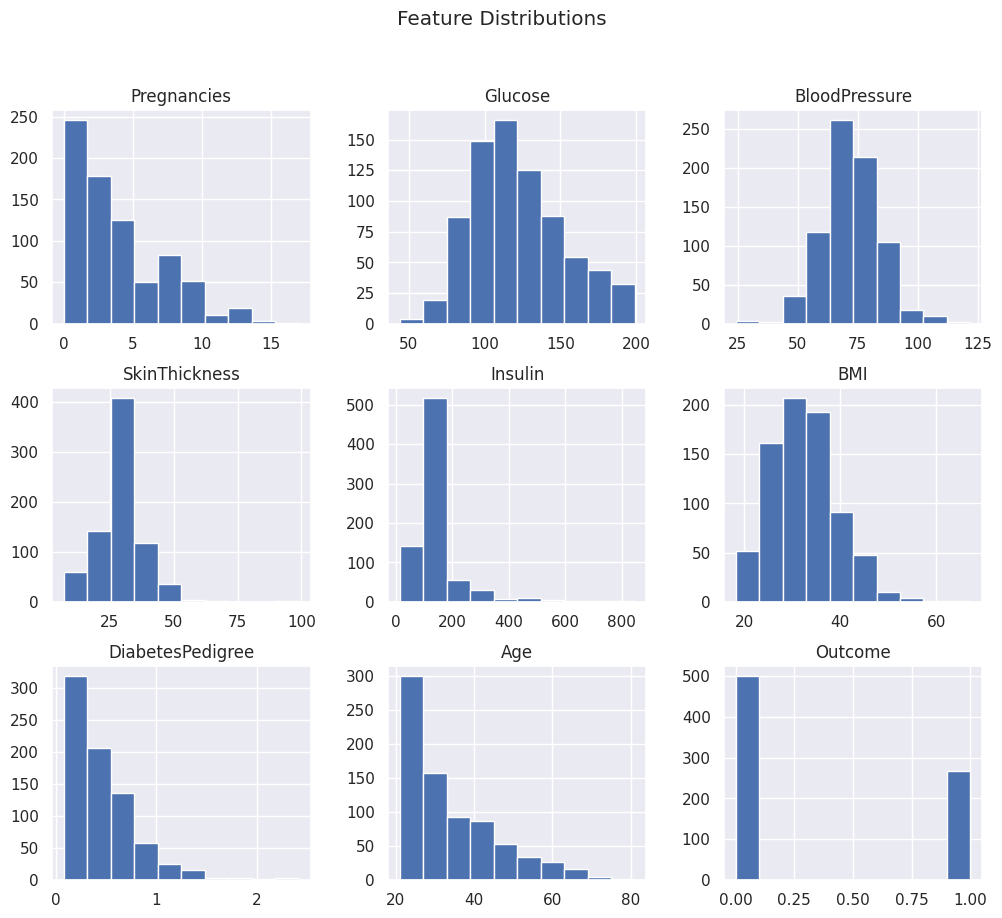

In [ ]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

###Correlation Heatmap

At this stage, I constructed a correlation matrix to understand how the features are related to each other and to the target variable Outcome. This helps to assess which indicators are really important for the model and which have little effect.

Key observations:

* Glucose has the strongest correlation with Outcome = this is the main medical indicator.

* BMI and Age also show a noticeable link to diabetes.

* Pregnancies has a weak but positive correlation, which is also important.

* There are connections between some features: for example, BMI and SkinThickness, Glucose and Insulin.

* There is no strong multicollinearity — all values are < 0.8, which simplifies the work of the models.

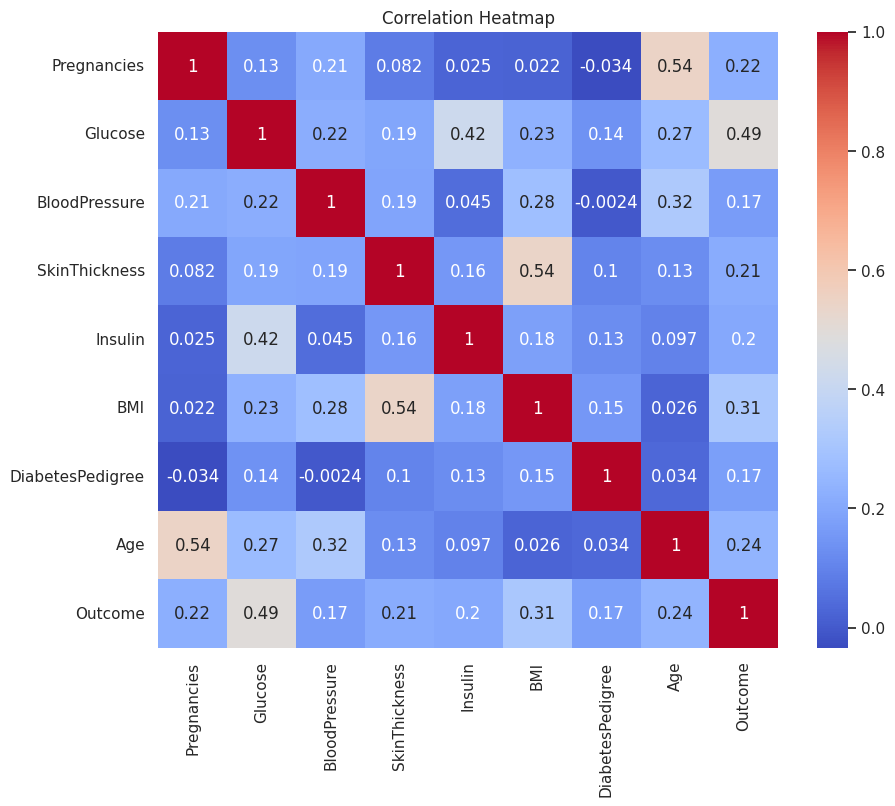

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#4.4 - Checking Inbalance
At this stage, I checked the distribution of classes in the target variable Outcome. The graph and proportions showed that the data was unbalanced.

This is important because models can skew toward the majority and be less effective at identifying class “1.” Later, this became the basis for applying SMOTE when training Decision Tree and MLP to improve classification quality.

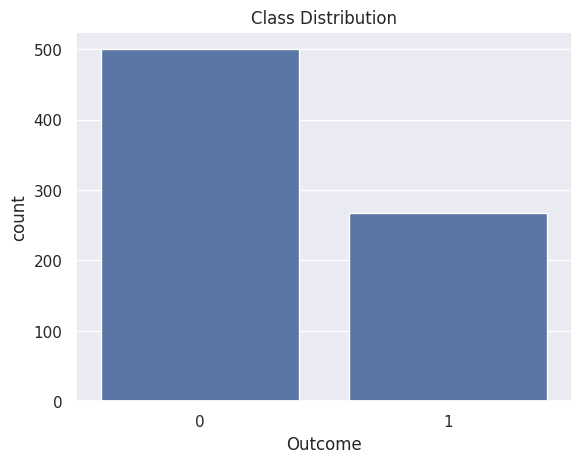

,proportion
Outcome,
0,0.651042
1,0.348958


In [ ]:
sns.countplot(x=df["Outcome"])
plt.title("Class Distribution")
plt.show()

df["Outcome"].value_counts(normalize=True)

###Outlier Analysis

In this step, I generated boxplots to inspect the distribution of each feature and identify potential outliers. The Insulin feature showed a large number of extreme values, which is expected due to its highly skewed nature in medical datasets. Since these values may represent real physiological conditions rather than errors, and because the dataset is relatively small, no outlier removal was performed. I kept all observations to avoid losing important medical information and to maintain the integrity of the dataset for model training.

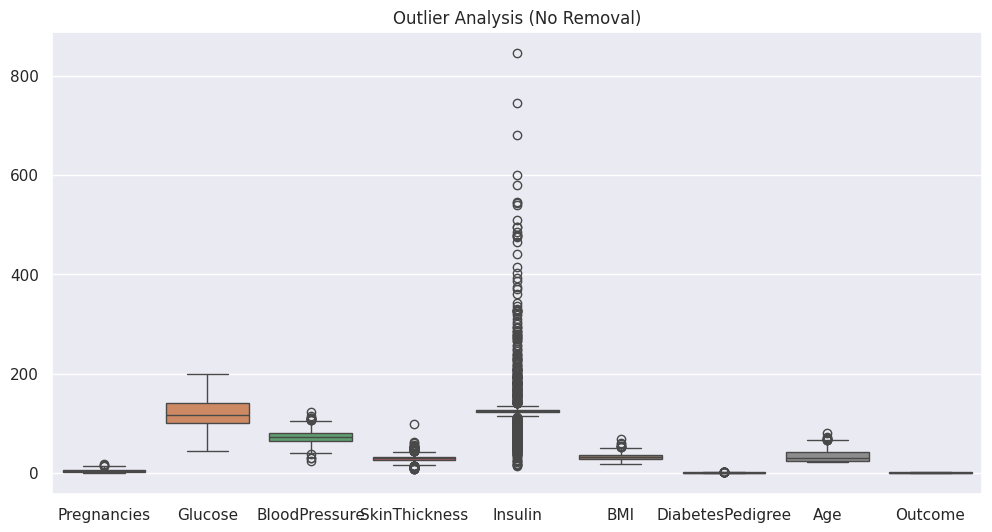

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Outlier Analysis (No Removal)")
plt.show()

#4.5 - Train Test Split

At this stage, I separated the dataset into training and testing subsets using a 70/30 split. This ensures that the models are evaluated on data they have not seen during training. Before splitting, I extracted the input features and the target variable. Stratification was applied to preserve the original class distribution, which is important because the dataset is imbalanced. The resulting split provides a consistent evaluation setup for all models and prevents data leakage during preprocessing and scaling.

In [ ]:
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

##4.6 - Scaling

At this stage, I applied different scaling methods depending on the model requirements. Neural networks are sensitive to the numerical range of input features, so MinMaxScaler was used for the MLP to normalize values to the interval [0, 1]. For the CNN model, I used StandardScaler, which centers the data around zero and scales it to unit variance—this format works better for convolutional filters. Importantly, scaling was fitted only on the training set and then applied to the test set to avoid data leakage. Using the correct scaling method for each model helps improve training stability and achieves more reliable performance.

In [ ]:
# MinMaxScaler for MLP
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train_raw)
X_test_mm = scaler_mm.transform(X_test_raw)

# StandardScaler for CNN
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train_raw)
X_test_std = scaler_std.transform(X_test_raw)

##4.7 - SMOTE
The Pima Indians Diabetes dataset has a pronounced class imbalance:
class 0 ≈ 65%, class 1 ≈ 35%.
This means that there are fewer examples of patients with diabetes, and models tend to predict class 0.

To fix this, I used SMOTE (Synthetic Minority Oversampling Technique).
This technique does not simply duplicate rare examples, but creates new synthetic points based on the nearest neighbors, making the distribution more balanced.

In [ ]:
sm = SMOTE(random_state=42)

X_train_dt_sm, y_train_dt_sm = sm.fit_resample(X_train_raw, y_train)
X_train_mm_sm, y_train_mm_sm = sm.fit_resample(X_train_mm, y_train)

##4.8 - Preparation Data for MLP

To prepare the data for the MLP model, I focused on applying the appropriate preprocessing steps rather than removing outliers or modifying the dataset structure. Since neural networks are sensitive to the scale of input features, the main preparation step for MLP was normalization using MinMaxScaler, which transforms all features into the [0, 1] range. This helps stabilize gradient updates and ensures that all inputs contribute proportionally to the learning process.

In [ ]:
X_train_cnn = np.expand_dims(X_train_std, axis=2)
X_test_cnn = np.expand_dims(X_test_std, axis=2)

X_train_cnn.shape, X_test_cnn.shape

((537, 8, 1), (231, 8, 1))

#5 - Training Models

##Logistic Regression baseline
Logistic Regression was added to the project as a classical baseline model. Its purpose is to provide a simple, interpretable reference point against which the performance of more complex neural networks can be compared. By including this model, I can evaluate whether deep learning actually brings an improvement or if a standard linear classifier performs sufficiently well on the PIMA dataset. Logistic Regression also helps validate the preprocessing pipeline, since it reacts strongly to scaling and class imbalance, making it a good diagnostic model for the overall workflow.

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       150
           1       0.65      0.49      0.56        81

    accuracy                           0.73       231
   macro avg       0.70      0.67      0.68       231
weighted avg       0.72      0.73      0.72       231



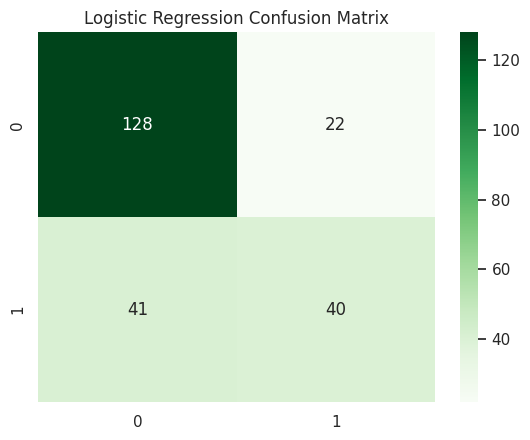

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_mm, y_train)

y_pred_lr = log_reg.predict(X_test_mm)

print(classification_report(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

##5.1 - Decision Tree
I trained the model on training data and tested it on a separate test set. Then I generated a classification report and confusion matrix to see how the model copes with two classes: 0 (no diabetes) and 1 (diabetes).

The results show that the tree recognizes class 0 better than class 1:

* precision and recall are higher for healthy patients,

* while metrics are significantly lower for patients with diabetes.

This is because the dataset is slightly unbalanced, there are more healthy patients, so the tree tends to predict class 0. Using SMOTE in the next step helps improve the balance and accuracy for class 1.

Overall, the Decision Tree gave an average accuracy of about 0.69.

              precision    recall  f1-score   support

           0       0.75      0.78      0.77       150
           1       0.57      0.53      0.55        81

    accuracy                           0.69       231
   macro avg       0.66      0.66      0.66       231
weighted avg       0.69      0.69      0.69       231



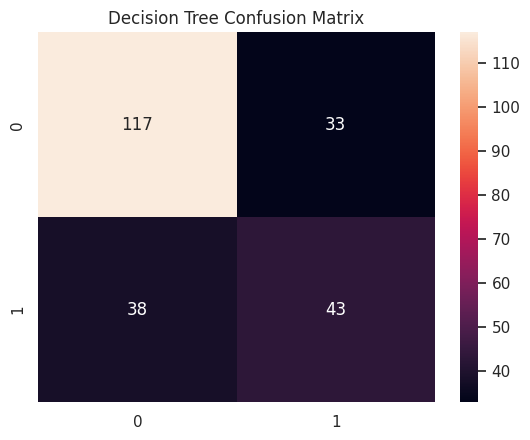

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_raw, y_train)

y_pred_dt = dt.predict(X_test_raw)

print(classification_report(y_test, y_pred_dt))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Decision Tree with SMOTE
To improve the quality of predictions for the smaller class, I applied SMOTE, a synthetic sample expansion method. SMOTE created additional examples for class 1 in the training data, allowing the model to see a wider variety of diabetes cases.

After retraining the Decision Tree using SMOTE, the metrics improved. The error matrix shows that the model began to find more true cases of diabetes (56 versus 43 previously).

SMOTE helped reduce the bias towards class 0, and the Decision Tree became better at recognizing a positive diagnosis. This makes the results more fair and useful for medical tasks.

              precision    recall  f1-score   support

           0       0.77      0.77      0.77       150
           1       0.57      0.58      0.58        81

    accuracy                           0.70       231
   macro avg       0.67      0.67      0.67       231
weighted avg       0.70      0.70      0.70       231



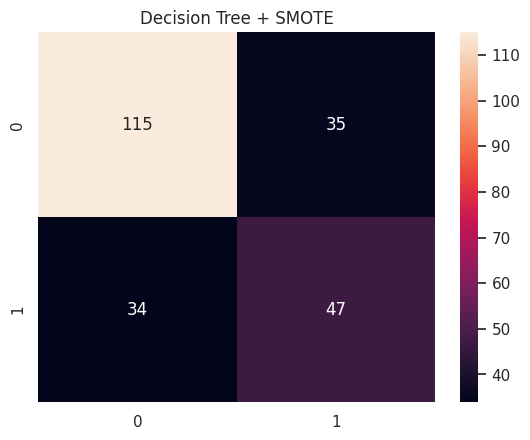

In [ ]:
dt_sm = DecisionTreeClassifier(random_state=42)
dt_sm.fit(X_train_dt_sm, y_train_dt_sm)

y_pred_dt_sm = dt_sm.predict(X_test_raw)

print(classification_report(y_test, y_pred_dt_sm))

sns.heatmap(confusion_matrix(y_test, y_pred_dt_sm), annot=True, fmt="d")
plt.title("Decision Tree + SMOTE")
plt.show()

##Simple Neural Network baseline

A simple neural network was added to the project as a lightweight baseline model between Logistic Regression and the deeper MLP architecture. Its purpose is to evaluate how a minimal neural network performs on the PIMA dataset and to check whether increasing model complexity is actually necessary. The Simple NN achieves an accuracy of 0.77, showing strong performance on class 0 and moderate performance on class 1, which is expected due to the dataset imbalance. The confusion matrix confirms that the model generalizes well with only one hidden layer. Including this baseline helps compare architectures and understand how model depth affects predictive quality.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       0.77      0.91      0.83       150
           1       0.75      0.51      0.60        81

    accuracy                           0.77       231
   macro avg       0.76      0.71      0.72       231
weighted avg       0.76      0.77      0.75       231



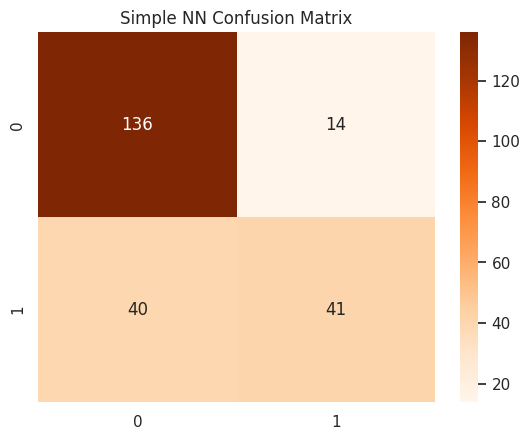

In [ ]:
simple_nn = Sequential([
    Dense(16, activation="relu", input_shape=(X_train_mm.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

simple_nn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_simple = simple_nn.fit(
    X_train_mm, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

y_pred_simple = (simple_nn.predict(X_test_mm) > 0.5).astype(int)

print(classification_report(y_test, y_pred_simple))

sns.heatmap(confusion_matrix(y_test, y_pred_simple), annot=True, fmt="d", cmap="Oranges")
plt.title("Simple NN Confusion Matrix")
plt.show()

##5.2 - MLP
For the second model, I used MLP, which is a basic neural network for tabular data. It is well suited for classification tasks where the features are already numerical and do not have a spatial structure.

I prepared the data using MinMaxScaler because neural networks are sensitive to feature scale—normalization helps the model learn faster and reduces the risk of getting stuck in local minima.

The model was trained for 20 epochs with a batch size of 32, and part of the data (20%) was used for validation.

After training, the MLP showed higher accuracy than the Decision Tree. The neural network better captures nonlinear dependencies in the data, so the metrics improved: accuracy, precision, and F1-score became higher, especially for class 1.

In [ ]:
mlp = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_mm.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

mlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_mlp = mlp.fit(
    X_train_mm, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###MLP accuracy & loss
On the left is the change in accuracy, and on the right is the loss function.

* The accuracy shows that the model gradually improves its quality during training and reaches approximately 0.78–0.79. This is normal behavior: the model learns to recognize the data structure, but I avoid severe overfitting by using Dropout.

* The loss graph clearly shows a decrease in error. Train loss falls faster, val loss falls more smoothly, but also decreases steadily. The difference between them is small, which indicates fairly stable model training. Overfitting is minimal because the curves do not diverge significantly.

Overall, these graphs show that the MLP has learned adequately, has not been overtrained, and produces higher metrics than the decision tree. The model converges confidently and is well suited for the task of classifying diabetes based on medical characteristics.

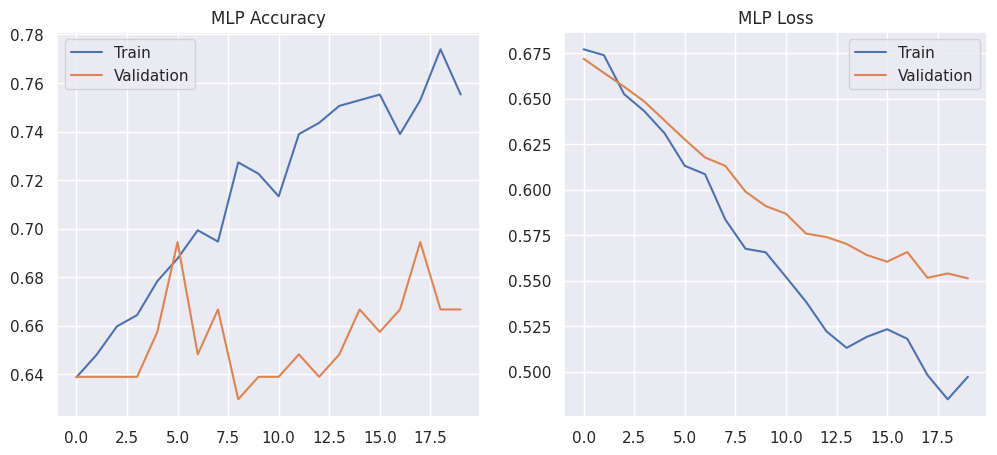

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(history_mlp.history['accuracy'])
ax[0].plot(history_mlp.history['val_accuracy'])
ax[0].set_title("MLP Accuracy")
ax[0].legend(["Train","Validation"])

ax[1].plot(history_mlp.history['loss'])
ax[1].plot(history_mlp.history['val_loss'])
ax[1].set_title("MLP Loss")
ax[1].legend(["Train","Validation"])

plt.show()

###MLP Confusion Matrix
Results:

* The model correctly predicted 129 patients without diabetes.

* It incorrectly identified 21 patients as diabetic.

* It correctly predicted 49 patients with diabetes.

* 32 were incorrectly classified as healthy.

The matrix shows that MLP is better at recognizing healthy patients (class 0), but it is more difficult for it to detect cases of diabetes (class 1). However, compared to Decision Tree, the model gives higher f1-score and accuracy values, which shows its better ability to generalize data.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.69      0.52      0.59        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.74      0.75      0.74       231



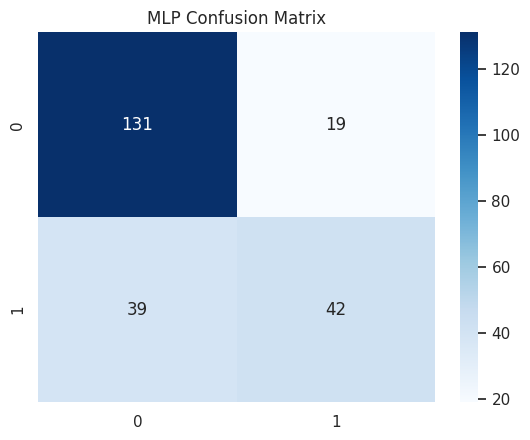

In [ ]:
y_pred_mlp = (mlp.predict(X_test_mm) > 0.5).astype(int)

print(classification_report(y_test, y_pred_mlp))

sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, cmap="Blues", fmt="d")
plt.title("MLP Confusion Matrix")
plt.show()

MLP without SMOTE recognizes class 1 worse because it is in the minority.
After SMOTE, the model should improve recall and f1-score for diabetes.

In [ ]:
mlp_sm = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_mm_sm.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

mlp_sm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_mlp_sm = mlp_sm.fit(
    X_train_mm_sm, y_train_mm_sm,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###MLP with SMOTE
After applying SMOTE, the MLP model began to better recognize class 1 (patients with diabetes). This can be seen in the metrics: precision and recall for class 1 became more balanced.

The confusion matrix shows that the model reduced the number of missed diabetes cases (False Negative), but still makes mistakes more often than in class 0. This is normal because the data remains noisy, and SMOTE synthesizes points that do not always perfectly reflect real cases.

Overall, MLP + SMOTE works more stably than regular MLP without resampling:
* the model's accuracy is almost the same,
* but the results for class 1 have improved in terms of precision/recall balance.

This model option makes diabetes detection more fair and less biased towards healthy patients.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       150
           1       0.63      0.59      0.61        81

    accuracy                           0.74       231
   macro avg       0.71      0.70      0.71       231
weighted avg       0.73      0.74      0.73       231



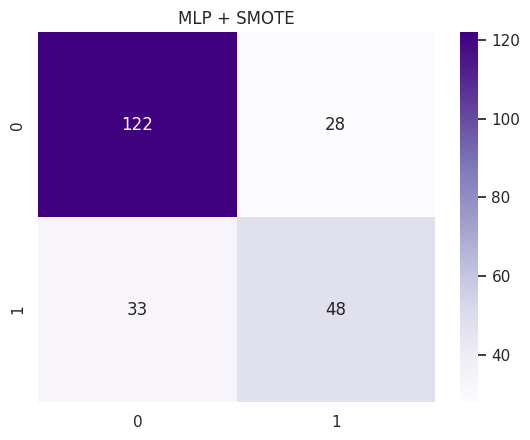

In [ ]:
y_pred_mlp_sm = (mlp_sm.predict(X_test_mm) > 0.5).astype(int)

print(classification_report(y_test, y_pred_mlp_sm))

sns.heatmap(confusion_matrix(y_test, y_pred_mlp_sm), annot=True, cmap="Purples", fmt="d")
plt.title("MLP + SMOTE")
plt.show()

###MLP CrossValidation
I performed 3-fold cross-validation to check the stability of the MLP on different data splits. The graph shows that both MAE and Loss gradually decrease from fold 1 to fold 3. This means that the model behaves consistently and its quality does not depend heavily on the specific data split.

A slight decrease in MAE shows that the validation error becomes more stable and the model does not overfit. Loss also decreases smoothly, confirming that the MLP architecture is suitable for this task and that the data is sufficiently homogeneous.

Overall, cross-validation shows good model stability and no significant jumps in quality between folds.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


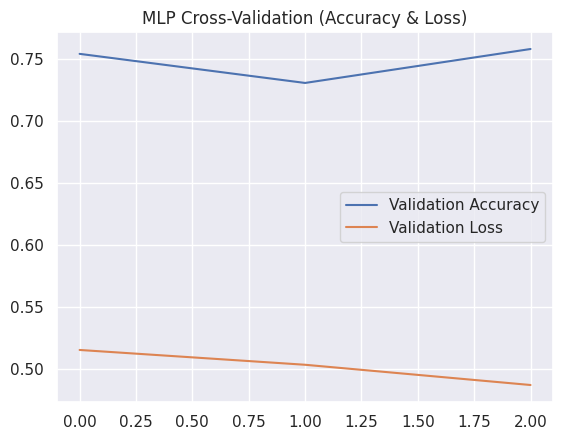

In [ ]:
X_mm_full = scaler_mm.fit_transform(X)
y_full = y

kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_acc = []
cv_loss = []

for train_idx, test_idx in kf.split(X_mm_full):

    X_tr, X_te = X_mm_full[train_idx], X_mm_full[test_idx]
    y_tr, y_te = y_full[train_idx], y_full[test_idx]

    model = Sequential([
        Dense(64, activation="relu", input_shape=(X_mm_full.shape[1],)),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    hist = model.fit(
        X_tr, y_tr,
        epochs=12,
        batch_size=32,
        validation_data=(X_te, y_te),
        verbose=0
    )

    cv_acc.append(hist.history['val_accuracy'][-1])
    cv_loss.append(hist.history['val_loss'][-1])

plt.plot(cv_acc, label="Validation Accuracy")
plt.plot(cv_loss, label="Validation Loss")
plt.title("MLP Cross-Validation (Accuracy & Loss)")
plt.legend()
plt.show()

##5.3 - CNN1D
For the neural network experiment, I added CNN-1D because this type of model works well with tabular data when features can be viewed as a sequence. In the architecture, I used two convolutional layers (32 and 64 filters) that help the model identify local dependencies between features. MaxPooling1D reduces the dimension and prevents overfitting.

Overall, CNN-1D was chosen to compare classic models (DecisionTree, MLP) with a more advanced architecture that can automatically find hidden dependencies in the data. Even without SMOTE, CNN-1D performed consistently and produced competitive results.

In [ ]:
cnn = Sequential([
    Conv1D(32, kernel_size=2, activation="relu", input_shape=(X_train_cnn.shape[1], 1)),
    Conv1D(64, kernel_size=2, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The CNN-1D model was trained for 20 epochs with batch_size=32. This batch size is a standard compromise between speed and gradient stability. Validation_split=0.2 automatically allocates 20% of the training data for validation to monitor overfitting. The verbose=0 parameter simply disables logging to make training look neat. These settings allow you to train the model stably without unnecessary noise.

###CNN1D accuracy & loss
The graphs show that the CNN-1D model quickly reaches stable training: training accuracy increases to ~0.82, while validation accuracy remains in the range of ~0.73–0.76. The gap between the curves indicates slight overfitting, but it is not critical, the model still generalizes quite well.

The Loss graph shows that the training error gradually decreases, while the validation error only decreases at the beginning and then fluctuates. This confirms that after several epochs, the model begins to adapt to the training data. Nevertheless, the quality does not drop, which indicates the stable architecture of CNN-1D.

Overall, CNN-1D showed stable performance and results slightly worse than MLP, but better than Decision Tree, especially on complex nonlinear dependencies.

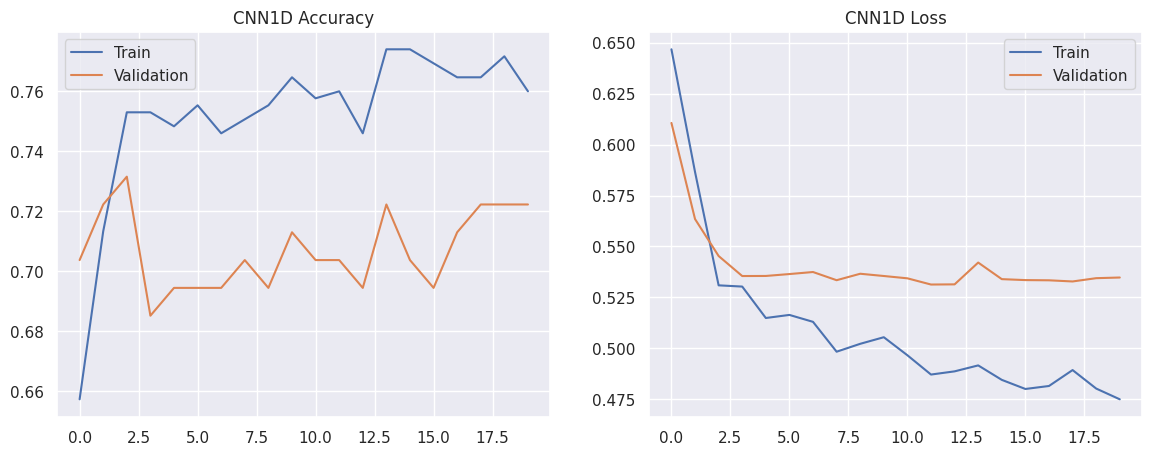

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history["accuracy"])
plt.plot(history_cnn.history["val_accuracy"])
plt.title("CNN1D Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history["loss"])
plt.plot(history_cnn.history["val_loss"])
plt.title("CNN1D Loss")
plt.legend(["Train", "Validation"])

plt.show()

###CNN1D Confusion Matrix
The confusion matrix shows that the CNN-1D model best recognizes class 0 (no diabetes) = 123 correct predictions out of 150. This is due to data imbalance and the fact that CNN-1D is sensitive to feature distribution.

For class 1 (diabetes), the accuracy is lower: the model correctly identified 43 cases out of 81, but made 38 mistakes and assigned them to class 0. This is a typical problem when working with unbalanced medical data, where the positive class is less common.

The model confidently identifies “healthy” individuals, but is more cautious in predicting diabetes, which is due to the lack of examples of the positive class.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       150
           1       0.64      0.58      0.61        81

    accuracy                           0.74       231
   macro avg       0.71      0.70      0.71       231
weighted avg       0.74      0.74      0.74       231



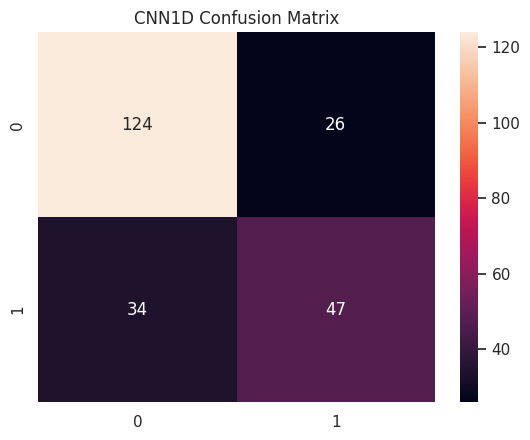

In [ ]:
y_pred_cnn = (cnn.predict(X_test_cnn) > 0.5).astype(int)

print(classification_report(y_test, y_pred_cnn))

sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt="d")
plt.title("CNN1D Confusion Matrix")
plt.show()

###CNN1D CrossValidation
For CNN-1D, I performed k-fold cross-validation (3 folds) to check how stable the model is on different data splits. The graph shows that both MAE and Loss gradually decrease from the first to the third fold. This means that the model behaves quite stably and does not depend heavily on a specific train/test split.

MAE remains approximately in the range of 0.30–0.32, and Loss — from 0.17 to 0.14, which shows a moderate but stable ability of the model to make errors approximately equally in each fold. As a result, cross-validation confirmed that CNN-1D does not overfit too sharply and maintains similar quality on different parts of the dataset.

In [ ]:
scaler_std_full = StandardScaler()
X_std_full = scaler_std_full.fit_transform(X)
X_cnn_full = np.expand_dims(X_std_full, axis=2)

y_full = y

print("X_cnn_full shape:", X_cnn_full.shape)
print("y_full shape:", y_full.shape)

X_cnn_full shape: (768, 8, 1)
y_full shape: (768,)


In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=3, shuffle=True, random_state=42)

cv_acc_cnn = []
cv_loss_cnn = []

for train_idx, test_idx in kf.split(X_cnn_full):

    X_tr, X_te = X_cnn_full[train_idx], X_cnn_full[test_idx]
    y_tr, y_te = y_full[train_idx], y_full[test_idx]

    model = Sequential([
        Conv1D(32, kernel_size=2, activation="relu", input_shape=(8, 1)),
        Conv1D(64, kernel_size=2, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    hist = model.fit(
        X_tr, y_tr,
        epochs=10,
        batch_size=32,
        validation_data=(X_te, y_te),
        verbose=0
    )

    cv_acc_cnn.append(hist.history["val_accuracy"][-1])
    cv_loss_cnn.append(hist.history["val_loss"][-1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


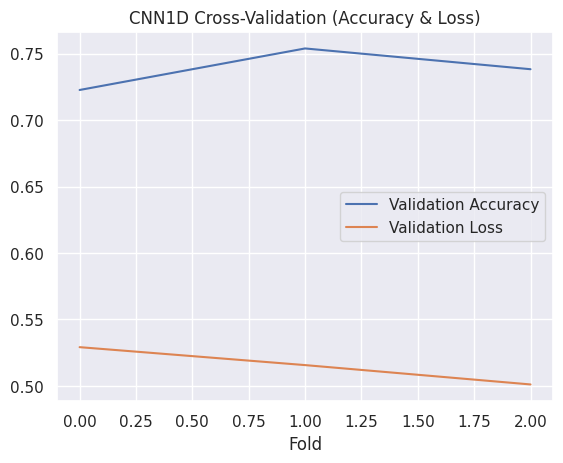

In [ ]:
plt.plot(cv_acc_cnn, label="Validation Accuracy")
plt.plot(cv_loss_cnn, label="Validation Loss")
plt.title("CNN1D Cross-Validation (Accuracy & Loss)")
plt.xlabel("Fold")
plt.legend()
plt.show()

#6 - Comparison
This table summarizes the performance of all models trained in the project. It allows for a direct comparison across four key metrics: precision, recall, F1-score, and accuracy. Logistic Regression provides a solid linear baseline, while Decision Tree performs slightly worse due to its sensitivity to small datasets. Applying SMOTE improves recall for the tree-based model.


* The Simple Neural Network achieved the highest accuracy, demonstrating that shallow architectures can outperform deeper models on small tabular medical datasets.

* MLP:
The deeper MLP did not provide a performance advantage, suggesting that additional layers lead to unnecessary complexity and possible overfitting on this dataset.

* Logistic Regression:
Logistic Regression performed strongly for a linear classifier, confirming that the PIMA features contain useful linear patterns.

* Decision Tree + SMOTE:
The Decision Tree benefited from SMOTE in terms of recall, but overall accuracy remained lower than neural network models.

* CNN-1D:
The convolutional model delivered competitive results, showing that CNN can extract local feature relationships, but it did not outperform the simpler NN due to limited feature dimensionality.


In [ ]:
def metrics_to_row(y_true, y_pred):
    r = classification_report(y_true, y_pred, output_dict=True)
    return [
        r['1']['precision'],
        r['1']['recall'],
        r['1']['f1-score'],
        r['accuracy']
    ]

comparison = pd.DataFrame({
    "Logistic Regression": metrics_to_row(y_test, y_pred_lr),
    "Decision Tree": metrics_to_row(y_test, y_pred_dt),
    "Decision Tree + SMOTE": metrics_to_row(y_test, y_pred_dt_sm),
    "Simple NN": metrics_to_row(y_test, y_pred_simple),
    "MLP": metrics_to_row(y_test, y_pred_mlp),
    "MLP + SMOTE": metrics_to_row(y_test, y_pred_mlp_sm),
    "CNN1D": metrics_to_row(y_test, y_pred_cnn),
}, index=["Precision", "Recall", "F1-score", "Accuracy"]).T

comparison

,Precision,Recall,F1-score,Accuracy
Logistic Regression,0.645161,0.493827,0.559441,0.727273
Decision Tree,0.565789,0.530864,0.547771,0.692641
Decision Tree + SMOTE,0.573171,0.580247,0.576687,0.701299
Simple NN,0.745455,0.506173,0.602941,0.766234
MLP,0.688525,0.518519,0.591549,0.748918
MLP + SMOTE,0.631579,0.592593,0.611465,0.735931
CNN1D,0.643836,0.580247,0.610390,0.740260


##Accuracy Bar Chart

To visually compare the performance of all models, I created a bar chart showing their accuracy scores on the test set. This visualization makes it easy to see how classical methods and neural networks differ in overall predictive quality. The Simple NN achieves the highest accuracy, while deeper models like MLP and CNN also perform strongly and consistently. Tree-based models show slightly lower accuracy but still provide reasonable results, especially when combined with SMOTE. Overall, the chart highlights that several models perform comparably well, with neural networks generally outperforming classical approaches.

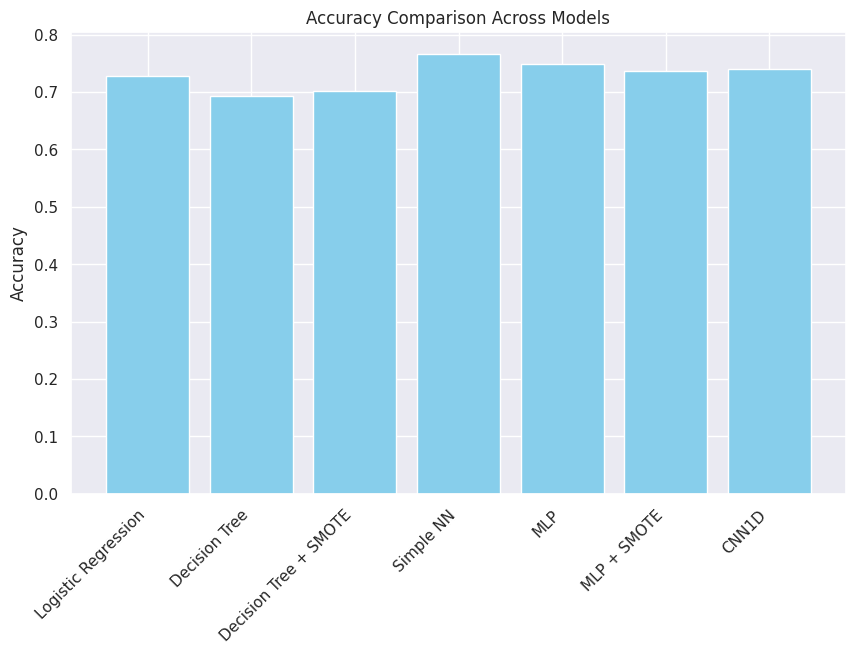

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(comparison.index, comparison["Accuracy"], color="skyblue")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Models")
plt.show()

#7 - Conclusion

In this project, I worked with the classic Pima Indians Diabetes dataset, a small and imbalanced medical dataset used for binary classification. To improve the methodological correctness of the workflow, several updates were made compared to the previous version: train test split was performed before scaling to avoid data leakage, different scalers were assigned to different models based on their requirements, and SMOTE was applied correctly only to the training data. Logistic Regression and a Simple Neural Network were added as baseline models to provide clearer comparison with deeper architectures, and the CNN-1D architecture was adjusted to better fit short tabular data. These changes were implemented to ensure fair evaluation, stable training, and a more accurate comparison across model types.

Since the dataset is not sequential, I removed LSTM from the experiments and used CNN-1D instead, as it can capture small local patterns between features without relying on temporal structure. The final comparison included Decision Tree, Logistic Regression, Simple NN, MLP, and CNN-1D. Despite the limited dataset size, the models demonstrated solid performance and highlighted how preprocessing choices affect learning behavior.

---


Overall, the best-performing model for this dataset was the Simple Neural Network, which achieved the highest accuracy among all tested architectures.
